# Data Loading

In [1]:
# Import the libraries required
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

In [2]:
# Load the Topo Chico dataset
df = pd.read_csv("datasets/topo chico_from_dump.csv")
df

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g
0,21136010374,MINERAL WATER CARBONATED,Topo Chico,undefined,united-states,"bottle-or-vial, bottle, glass-bottle",NaN,NaN,a,NaN,NaN,CARBONATED MINERAL WATER BOTTLED ONLY AT SOURCE.,NaN,NaN
1,21136010480,Agua Mineral,Cia. Topo Chico S.A.,"beverages-and-beverages-preparations, beverage...","mexico, united-states",NaN,NaN,NaN,a,4.0,NaN,MINERAL WATER AND CARBON DIOXIDE.,NaN,NaN
2,21136010626,"Topo Chico, Sparkling Carbonatada Agua Mineral...",Cia. Topo Chico S.A.,"beverages, waters",united-states,NaN,NaN,NaN,unknown,4.0,NaN,"Mineral water, carbon dioxide.",NaN,NaN
3,21136011500,Soda,Cia. Topo Chico S.A.,"beverages, carbonated-drinks, sodas",united-states,NaN,NaN,NaN,e,4.0,not-applicable,"Carbonated water, cane sugar, artificial and n...",10.99,42.0
4,21136011579,"Topo Chico, Carbonated Beverage, Apple",Cia. Topo Chico S.A.,"beverages, carbonated-drinks, sodas",united-states,NaN,NaN,NaN,e,4.0,not-applicable,"Carbonated water, cane sugar, citric acid, car...",12.24,49.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,993350000724,Topo chico,NaN,NaN,mexico,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
77,810078782193,Margarita Flavored Alcohol Beverage,Topo Chico,NaN,united-states,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
78,721136000480,Topo chico 1.5L,NaN,NaN,mexico,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
79,1219258,Raspberry with Lemon Flavored Sparkling Water,Topo Chico Sabores,NaN,united-states,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN


# Data Cleaning

In [3]:
# Inspect the data types of all columns to identify any required conversions.
df.dtypes

code                            object
product_name                       str
brands                             str
categories_tags                    str
countries_tags                     str
packaging_tags                     str
stores                             str
purchase_places                    str
nutriscore_grade                   str
nova_group                     float64
ecoscore_grade                     str
ingredients_text                   str
nutriments.sugars_100g         float64
nutriments.energy-kcal_100g    float64
dtype: object

In [4]:
# Examine the product code values before converting the column to a numeric type.
df.code.unique()

array([21136010374, 21136010480, 21136010626, 21136011500, 21136011579,
       21136013504, 21136013573, 21136014501, 21136015508, 21136016185,
       21136019506, 21136019575, 21136020373, 21136050462, 21136110180,
       21136120448, 21136414370, 21136616507, 21136010541, 21136010534,
       5449000294722, 5449000294746, 21136180619, 5449000294708,
       21136180657, 21136010350, 21136180794, 21136016444, 5000112650150,
       21136180800, 5449000300904, 21136180817, 21136180558, 21136180954,
       21136180701, 21136180664, 810078780014, 2004361007713,
       91055901860836515341, 21136180596, 21136180626, 21136010121,
       810078780045, 810078780342, 21136180947, 810078780021, 21136181166,
       5000112650167, 21136110449, 810078780564, 810078781035,
       7894900335040, 7894900335095, 7894900335026, 7501055379866,
       628068270380, 21136181371, 4774537447244, 21266181371, 21136181678,
       21136181708, 3118153, 21266010541, 21136181616, 2113618136,
       21136181623, 78

In [5]:
# Convert the product code column to float format first cauz values are big.
df=df.astype({"code": "float64"})

In [6]:
# Convert the product code column to integer format.
df=df.astype({"code": "int64"})

In [7]:
# Review the unique brand names to identify inconsistent spellings.
df.brands.unique()

<ArrowStringArray>
[           'Topo Chico', 'Cia. Topo Chico  S.A.',                     nan,
     'Coca-Cola Company',            'Topo chico',            'topo chico',
             'Too Chico',            'TOPO CHICO',    'Topo Chico Sabores',
       'Topo Chico Hard']
Length: 10, dtype: str

In [8]:
# Standardize brand names by correcting inconsistent spellings and capitalization.
# This ensures all variations of the same brand are grouped together.
df.brands = df.brands.replace({
    "Topo chico": "Topo Chico",
    "topo chico": "Topo Chico",
    "TOPO CHICO": "Topo Chico",
    "Too Chico": "Topo Chico"
}, regex=True)

In [9]:
# Replace missing brand values with 'Unknown' to avoid null values.
df.brands = df.brands.fillna("unknown")
df.brands.isnull().sum()

np.int64(0)

In [10]:
# Replace missing values in selected categorical columns with 'Unknown'.
cols = [
    "categories_tags",
    "countries_tags",
    "packaging_tags",
    "stores",
    "purchase_places",
    "ecoscore_grade",
    "ingredients_text"
]

df[cols] = df[cols].fillna("Unknown")

# Data Preparation

In [11]:
# Create a cleaned copy of the dataset.
# All subsequent preprocessing steps are performed on this copy to preserve the original data.
df_clean = df.copy()

In [12]:
# Split multiple country tags into individual rows and standardize
# the text by trimming spaces and converting to lowercase.
country_df = df_clean.copy()
country_df["countries_tags"] = country_df["countries_tags"].str.split(",")
country_df = country_df.explode("countries_tags")
country_df["countries_tags"] = country_df["countries_tags"].str.strip().str.lower()


In [13]:
# Split multiple packaging tags into separate rows and standardize
# the values for accurate packaging analysis.
pack_df = df_clean.copy()
pack_df["packaging_tags"] = pack_df["packaging_tags"].str.split(",")
pack_df = pack_df.explode("packaging_tags")
pack_df["packaging_tags"] = pack_df["packaging_tags"].str.strip().str.lower()

In [14]:
# Split multiple category tags into separate rows and standardize
# the text for consistent category analysis.
cat_df = df_clean.copy()
cat_df["categories_tags"] = cat_df["categories_tags"].str.split(",")
cat_df = cat_df.explode("categories_tags")
cat_df["categories_tags"] = cat_df["categories_tags"].str.strip().str.lower()

In [15]:
# Split multiple store names into individual rows and standardize
# the values for store-level analysis.
store_df = df_clean.copy()
store_df["stores"] = store_df["stores"].str.split(",")
store_df = store_df.explode("stores")
store_df["stores"] = store_df["stores"].str.strip().str.lower()

In [16]:
# Display the frequency of each brand.
df.brands.value_counts()

brands
Topo Chico               44
unknown                  16
Cia. Topo Chico  S.A.    15
Topo Chico Sabores        4
Coca-Cola Company         1
Topo Chico Hard           1
Name: count, dtype: int64

In [17]:
# Display the number of products available in each country.
country_df.value_counts("countries_tags")

countries_tags
united-states    60
spain             6
mexico            5
brazil            3
luxembourg        2
germany           2
unknown           1
france            1
italy             1
saudi-arabia      1
japan             1
Name: count, dtype: int64

In [18]:
# Display the frequency of each packaging type.
pack_df.value_counts("packaging_tags")

packaging_tags
unknown                          72
bottle                            5
metal                             3
recyclable-metals                 3
aluminium                         3
bottle-or-vial                    1
glass-bottle                      1
pet-desechable-con-taparrosca     1
de:al                             1
Name: count, dtype: int64

In [19]:
# Display the frequency of each product category.
cat_df.value_counts("categories_tags")

categories_tags
beverages                               44
unknown                                 34
beverages-and-beverages-preparations    22
waters                                  20
carbonated-drinks                       15
alcoholic-beverages                     13
carbonated-waters                        8
spring-waters                            7
mineral-waters                           7
sodas                                    7
hard-seltzer                             4
undefined                                3
carbonated-mineral-waters                2
hard-seltzers                            2
premixed-alcoholic-beverages             2
vodka-based-alcoholic-beverages          2
wines                                    1
de:alcopop                               1
de:alkoholhaltiges-mischgetränk          1
de:alkopop                               1
de:hard-seltzer                          1
de:premixgetränk                         1
de:ready-to-drink                     

In [20]:
# Display the frequency of products available across stores.
store_df.value_counts("stores")

stores
unknown         77
carrefour.fr     2
la plancha       1
méxico           1
soriana          1
abarrotes        1
chedraui         1
walmart          1
sam's            1
hagebaumarkt     1
Name: count, dtype: int64

In [21]:
# Calculate the total number of unique brands.
print("Total Brands :", df["brands"].nunique())

Total Brands : 6


In [22]:
# Calculate the total number of unique categories.
print("Total Categories :", cat_df["categories_tags"].nunique())

Total Categories : 25


In [23]:
# Calculate the total number of unique countries.
print("Total Countries :", country_df["countries_tags"].nunique())

Total Countries : 11


In [24]:
# Calculate the total number of unique packaging types.
print("Total Packaging Types :", pack_df["packaging_tags"].nunique())

Total Packaging Types : 9


In [25]:
# Calculate the total number of unique stores.
print("Total Stores :", store_df["stores"].nunique())

Total Stores : 10


# Dataset Summary

In [26]:
# Convert all non-numeric columns to object type to ensure
df[df.select_dtypes(exclude='number').columns] = df.select_dtypes(exclude='number').astype(object)

In [27]:
# Create a summary table showing the number of unique values,
# missing values, and data type for each column.
# This provides an overview of the dataset after preprocessing.
summary = pd.DataFrame({
    "Unique Values": df.nunique(),
    "Missing Values": df.isnull().sum(),
    "Data Type": df.dtypes
})

summary

,Unique Values,Missing Values,Data Type
code,81,0,int64
product_name,65,0,object
brands,6,0,object
categories_tags,18,0,object
countries_tags,13,0,object
packaging_tags,6,0,object
stores,4,0,object
purchase_places,2,0,object
nutriscore_grade,6,0,object
nova_group,2,43,float64


# First lets analyze one column at a time 

Brands

In [28]:
# Check brand statistics and frequency distribution.
print(df["brands"].describe())

df["brands"].value_counts()

count             81
unique             6
top       Topo Chico
freq              44
Name: brands, dtype: object


brands
Topo Chico               44
unknown                  16
Cia. Topo Chico  S.A.    15
Topo Chico Sabores        4
Coca-Cola Company         1
Topo Chico Hard           1
Name: count, dtype: int64

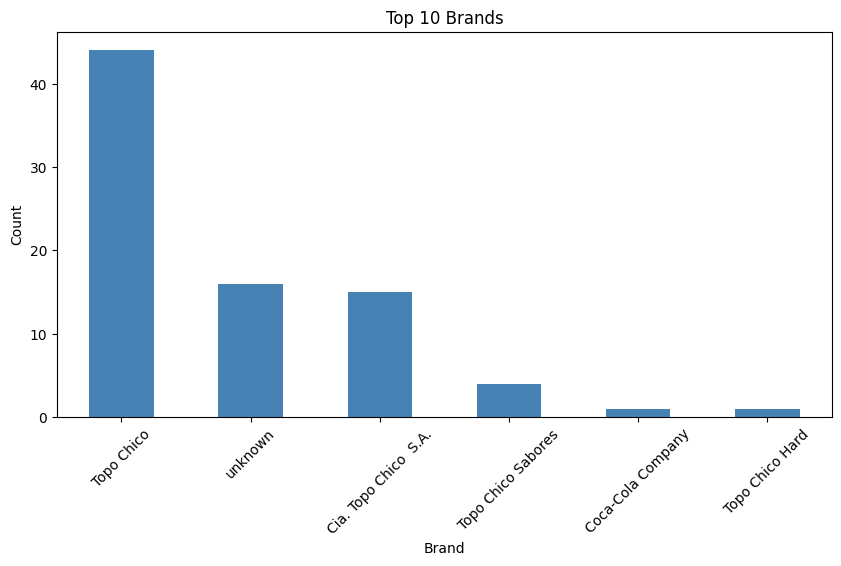

In [29]:
# Visualize the most common brands.
plt.figure(figsize=(10,5))

df["brands"].value_counts().head(10).plot(
    kind="bar",
    color="steelblue"
)

plt.title("Top 10 Brands")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

Categories

In [30]:
# Check the most common product categories.
cat_df["categories_tags"].value_counts().head(15)

categories_tags
beverages                               44
unknown                                 34
beverages-and-beverages-preparations    22
waters                                  20
carbonated-drinks                       15
alcoholic-beverages                     13
carbonated-waters                        8
spring-waters                            7
mineral-waters                           7
sodas                                    7
hard-seltzer                             4
undefined                                3
carbonated-mineral-waters                2
hard-seltzers                            2
premixed-alcoholic-beverages             2
Name: count, dtype: int64

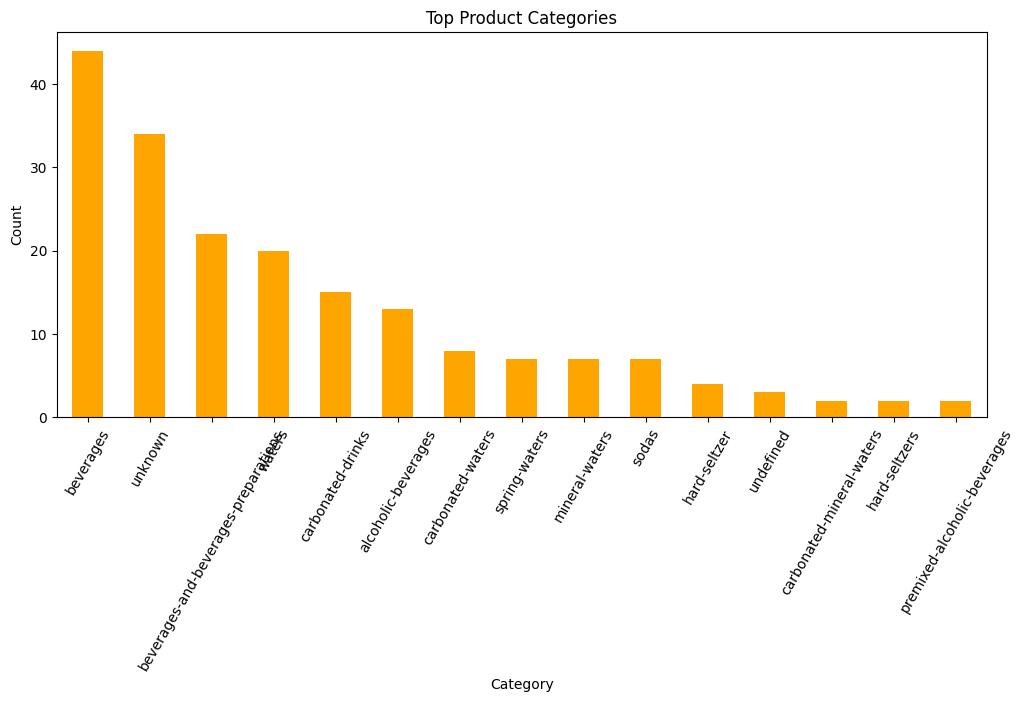

In [31]:
# Visualize the most common product categories.
plt.figure(figsize=(12,5))

cat_df["categories_tags"].value_counts().head(15).plot(
    kind="bar",
    color="orange"
)

plt.title("Top Product Categories")
plt.xlabel("Category")
plt.ylabel("Count")

plt.xticks(rotation=60)

plt.show()

Countries

In [32]:
# Check the countries with the highest number of products.
country_df["countries_tags"].value_counts().head(15)

countries_tags
united-states    60
spain             6
mexico            5
brazil            3
luxembourg        2
germany           2
unknown           1
france            1
italy             1
saudi-arabia      1
japan             1
Name: count, dtype: int64

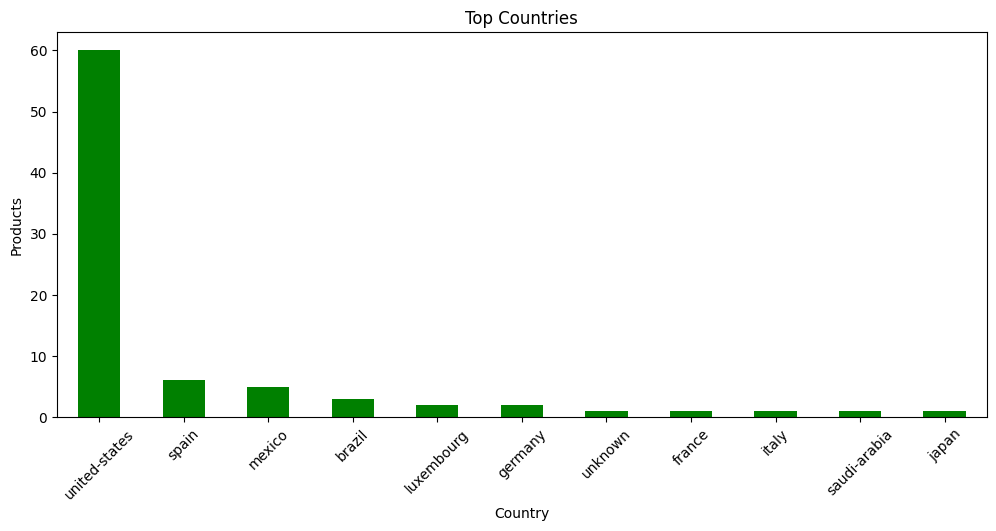

In [33]:
# Visualize product counts across countries.
plt.figure(figsize=(12,5))

country_df["countries_tags"].value_counts().plot(
    kind="bar",
    color="green"
)

plt.title("Top Countries")
plt.xlabel("Country")
plt.ylabel("Products")

plt.xticks(rotation=45)

plt.show()

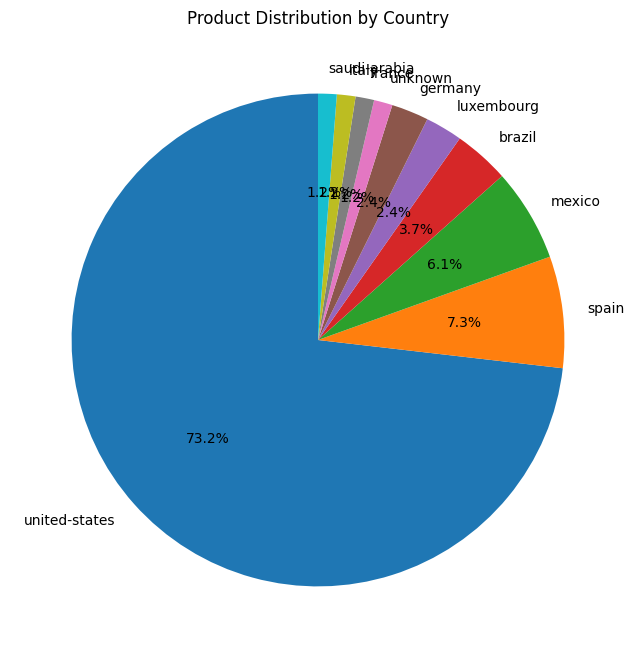

In [34]:
# Visualize the top 10 countries as a percentage distribution.
top10 = country_df["countries_tags"].value_counts().head(10)

plt.figure(figsize=(8,8))

plt.pie(
    top10,
    labels=top10.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Product Distribution by Country")

plt.show()

Packaging

In [35]:
# Check the most common packaging types.
pack_df["packaging_tags"].value_counts().head(15)

packaging_tags
unknown                          72
bottle                            5
metal                             3
recyclable-metals                 3
aluminium                         3
bottle-or-vial                    1
glass-bottle                      1
pet-desechable-con-taparrosca     1
de:al                             1
Name: count, dtype: int64

Stores

In [36]:
# Check the stores with the highest product counts.
store_df["stores"].value_counts().head(15)

stores
unknown         77
carrefour.fr     2
la plancha       1
méxico           1
soriana          1
abarrotes        1
chedraui         1
walmart          1
sam's            1
hagebaumarkt     1
Name: count, dtype: int64

Purchase Places

In [37]:
# Check the most common product purchase locations.
df["purchase_places"].value_counts().head(15)

purchase_places
Unknown        80
Deutschland     1
Name: count, dtype: int64

Eco Score

In [38]:
# Check the distribution of EcoScore grades.
df["ecoscore_grade"].value_counts()

ecoscore_grade
Unknown           57
unknown           16
not-applicable     8
Name: count, dtype: int64

In [39]:
# Create a separate dataframe for country-level analysis.
country_df = df.copy()

# Split products containing multiple countries.
country_df["countries_tags"] = (
    country_df["countries_tags"]
    .fillna("")
    .str.split(",")
)

# Create one row for each country.
country_df = country_df.explode("countries_tags")

# Standardize country names.
country_df["countries_tags"] = (
    country_df["countries_tags"]
    .str.strip()
    .str.lower()
)

# Remove rows without a country value.
country_df = country_df[
    country_df["countries_tags"] != ""
]

country_df.head()

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g
0,21136010374,MINERAL WATER CARBONATED,Topo Chico,undefined,united-states,"bottle-or-vial, bottle, glass-bottle",Unknown,Unknown,a,NaN,Unknown,CARBONATED MINERAL WATER BOTTLED ONLY AT SOURCE.,NaN,NaN
1,21136010480,Agua Mineral,Cia. Topo Chico S.A.,"beverages-and-beverages-preparations, beverage...",mexico,Unknown,Unknown,Unknown,a,4.0,Unknown,MINERAL WATER AND CARBON DIOXIDE.,NaN,NaN
1,21136010480,Agua Mineral,Cia. Topo Chico S.A.,"beverages-and-beverages-preparations, beverage...",united-states,Unknown,Unknown,Unknown,a,4.0,Unknown,MINERAL WATER AND CARBON DIOXIDE.,NaN,NaN
2,21136010626,"Topo Chico, Sparkling Carbonatada Agua Mineral...",Cia. Topo Chico S.A.,"beverages, waters",united-states,Unknown,Unknown,Unknown,unknown,4.0,Unknown,"Mineral water, carbon dioxide.",NaN,NaN
3,21136011500,Soda,Cia. Topo Chico S.A.,"beverages, carbonated-drinks, sodas",united-states,Unknown,Unknown,Unknown,e,4.0,not-applicable,"Carbonated water, cane sugar, artificial and n...",10.99,42.0


Country-wise product count

In [40]:
# Calculate the number of unique products for each country.
country_product_count = (
    country_df.groupby("countries_tags")["code"]
    .nunique()
    .sort_values(ascending=False)
)

country_product_count.head(20)

countries_tags
united-states    60
spain             6
mexico            5
brazil            3
germany           2
luxembourg        2
france            1
italy             1
japan             1
saudi-arabia      1
unknown           1
Name: code, dtype: int64

Country-wise average calories & sugar

In [41]:
# Calculate product count, average calories, and average sugar by country.
country_nutrition = (
    country_df.groupby("countries_tags")
    .agg(
        Products=("code", "nunique"),
        Avg_Calories=("nutriments.energy-kcal_100g", "mean"),
        Avg_Sugar=("nutriments.sugars_100g", "mean")
    )
    .reset_index()
)

country_nutrition = country_nutrition.sort_values(
    "Products",
    ascending=False
)

country_nutrition.head(20)

,countries_tags,Products,Avg_Calories,Avg_Sugar
9,united-states,60,20.301478,3.398282
8,spain,6,NaN,NaN
6,mexico,5,NaN,NaN
0,brazil,3,NaN,NaN
2,germany,2,NaN,NaN
5,luxembourg,2,29.500000,3.400000
1,france,1,NaN,NaN
3,italy,1,NaN,NaN
4,japan,1,5.000000,NaN
7,saudi-arabia,1,27.500000,0.423000


Nutrition-score distribution by country

In [42]:
# Prepare clean country data for nutrition-score analysis.
country_df = country_df.reset_index(drop=True)

# Remove products without a nutrition grade.
nutrition_data = country_df.dropna(
    subset=["nutriscore_grade"]
).copy()

# Remove rows without valid country names.
nutrition_data = nutrition_data[
    nutrition_data["countries_tags"].notna() &
    (nutrition_data["countries_tags"] != "")
]

# Compare nutrition-score grades across countries.
nutrition_by_country = pd.crosstab(
    nutrition_data["countries_tags"],
    nutrition_data["nutriscore_grade"]
)

nutrition_by_country

nutriscore_grade,a,b,c,e,not-applicable,unknown
countries_tags,,,,,,
brazil,0,0,0,0,0,3
france,0,0,0,0,0,1
germany,0,0,0,0,2,0
italy,0,0,0,0,0,1
japan,0,0,0,0,0,1
luxembourg,0,0,0,0,2,0
mexico,2,1,0,0,0,2
saudi-arabia,0,0,0,0,1,0
spain,1,0,1,0,0,4


Percentage of each Nutrition Grade

In [43]:
# Calculate the percentage distribution of nutrition grades by country.
nutrition_percentage = pd.crosstab(
    nutrition_data["countries_tags"],
    nutrition_data["nutriscore_grade"],
    normalize="index"
) * 100

nutrition_percentage = nutrition_percentage.round(2)

nutrition_percentage.head(20)

nutriscore_grade,a,b,c,e,not-applicable,unknown
countries_tags,,,,,,
brazil,0.00,0.00,0.00,0.00,0.00,100.00
france,0.00,0.00,0.00,0.00,0.00,100.00
germany,0.00,0.00,0.00,0.00,100.00,0.00
italy,0.00,0.00,0.00,0.00,0.00,100.00
japan,0.00,0.00,0.00,0.00,0.00,100.00
luxembourg,0.00,0.00,0.00,0.00,100.00,0.00
mexico,40.00,20.00,0.00,0.00,0.00,40.00
saudi-arabia,0.00,0.00,0.00,0.00,100.00,0.00
spain,16.67,0.00,16.67,0.00,0.00,66.67


Average sugar by country

In [44]:
# Calculate and rank the average sugar content by country.
sugar_by_country = (
    country_df.groupby("countries_tags")
    ["nutriments.sugars_100g"]
    .mean()
    .sort_values(ascending=False)
)

sugar_by_country.head(20)

countries_tags
luxembourg       3.400000
united-states    3.398282
unknown          0.600000
saudi-arabia     0.423000
brazil                NaN
france                NaN
germany               NaN
italy                 NaN
japan                 NaN
mexico                NaN
spain                 NaN
Name: nutriments.sugars_100g, dtype: float64

Average calories by country

In [45]:
# Calculate and rank the average calorie content by country.
calories_by_country = (
    country_df.groupby("countries_tags")
    ["nutriments.energy-kcal_100g"]
    .mean()
    .sort_values(ascending=False)
)

calories_by_country.head(20)

countries_tags
luxembourg       29.500000
unknown          29.000000
saudi-arabia     27.500000
united-states    20.301478
japan             5.000000
brazil                 NaN
france                 NaN
germany                NaN
italy                  NaN
mexico                 NaN
spain                  NaN
Name: nutriments.energy-kcal_100g, dtype: float64

EcoScore analysis

In [46]:
# Calculate the percentage of each EcoScore category by country.
eco_by_country = pd.crosstab(
    country_df["countries_tags"],
    country_df["ecoscore_grade"],
    normalize="index"
) * 100

eco_by_country.round(2).head(20)

ecoscore_grade,Unknown,not-applicable,unknown
countries_tags,,,
brazil,100.00,0.00,0.0
france,100.00,0.00,0.0
germany,100.00,0.00,0.0
italy,100.00,0.00,0.0
japan,0.00,0.00,100.0
luxembourg,0.00,0.00,100.0
mexico,100.00,0.00,0.0
saudi-arabia,0.00,0.00,100.0
spain,100.00,0.00,0.0


NOVA processing level

In [47]:
# Calculate the percentage of each NOVA group by country.
nova_by_country = pd.crosstab(
    country_df["countries_tags"],
    country_df["nova_group"],
    normalize="index"
) * 100

nova_by_country.round(2).head(20)

nova_group,1.0,4.0
countries_tags,,
germany,0.00,100.00
mexico,66.67,33.33
saudi-arabia,0.00,100.00
spain,100.00,0.00
united-states,6.06,93.94
unknown,0.00,100.00


# Country Analysis Function

In [48]:
# Create a reusable function to summarize a country's product data.
def analyze_country(country):

    data = country_df[
        country_df["countries_tags"] == country.lower()
    ]

    print(f"COUNTRY: {country.upper()}")
    print("=" * 50)

    print(f"Products: {data['code'].nunique()}")

    print(
        f"Average Calories: "
        f"{data['nutriments.energy-kcal_100g'].mean():.2f} kcal/100g"
    )

    print(
        f"Average Sugar: "
        f"{data['nutriments.sugars_100g'].mean():.2f} g/100g"
    )

    print("\nNutrition Score Distribution:")
    print(
        data["nutriscore_grade"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    print("\nNOVA Distribution:")
    print(
        data["nova_group"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    print("\nEcoScore Distribution:")
    print(
        data["ecoscore_grade"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

In [49]:
# Generate the complete analysis for the United States.
analyze_country("united-states")

COUNTRY: UNITED-STATES
Products: 60
Average Calories: 20.30 kcal/100g
Average Sugar: 3.40 g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown           41.67
e                 16.67
b                 16.67
a                 13.33
not-applicable    11.67
Name: proportion, dtype: float64

NOVA Distribution:
nova_group
4.0    93.94
1.0     6.06
Name: proportion, dtype: float64

EcoScore Distribution:
ecoscore_grade
Unknown           66.67
unknown           20.00
not-applicable    13.33
Name: proportion, dtype: float64


In [50]:
# Generate the complete analysis for Mexico.
analyze_country("mexico")

COUNTRY: MEXICO
Products: 5
Average Calories: nan kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
nutriscore_grade
a          40.0
unknown    40.0
b          20.0
Name: proportion, dtype: float64

NOVA Distribution:
nova_group
1.0    66.67
4.0    33.33
Name: proportion, dtype: float64

EcoScore Distribution:
ecoscore_grade
Unknown    100.0
Name: proportion, dtype: float64


In [51]:
# Generate the complete analysis for Spain.
analyze_country("spain")

COUNTRY: SPAIN
Products: 6
Average Calories: nan kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown    66.67
a          16.67
c          16.67
Name: proportion, dtype: float64

NOVA Distribution:
nova_group
1.0    100.0
Name: proportion, dtype: float64

EcoScore Distribution:
ecoscore_grade
Unknown    100.0
Name: proportion, dtype: float64


In [52]:
# Generate the complete analysis for Luxembourg.
analyze_country("luxembourg")

COUNTRY: LUXEMBOURG
Products: 2
Average Calories: 29.50 kcal/100g
Average Sugar: 3.40 g/100g

Nutrition Score Distribution:
nutriscore_grade
not-applicable    100.0
Name: proportion, dtype: float64

NOVA Distribution:
Series([], Name: proportion, dtype: float64)

EcoScore Distribution:
ecoscore_grade
unknown    100.0
Name: proportion, dtype: float64


In [53]:
# Generate the complete analysis for germany.
analyze_country("germany")

COUNTRY: GERMANY
Products: 2
Average Calories: nan kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
nutriscore_grade
not-applicable    100.0
Name: proportion, dtype: float64

NOVA Distribution:
nova_group
4.0    100.0
Name: proportion, dtype: float64

EcoScore Distribution:
ecoscore_grade
Unknown    100.0
Name: proportion, dtype: float64


In [54]:
# Generate the complete analysis for France.
analyze_country("france")

COUNTRY: FRANCE
Products: 1
Average Calories: nan kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown    100.0
Name: proportion, dtype: float64

NOVA Distribution:
Series([], Name: proportion, dtype: float64)

EcoScore Distribution:
ecoscore_grade
Unknown    100.0
Name: proportion, dtype: float64


In [55]:
# Generate the complete analysis for Italy.
analyze_country("italy")

COUNTRY: ITALY
Products: 1
Average Calories: nan kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown    100.0
Name: proportion, dtype: float64

NOVA Distribution:
Series([], Name: proportion, dtype: float64)

EcoScore Distribution:
ecoscore_grade
Unknown    100.0
Name: proportion, dtype: float64


In [56]:
# Generate the complete analysis for Brazil.
analyze_country("brazil")

COUNTRY: BRAZIL
Products: 3
Average Calories: nan kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown    100.0
Name: proportion, dtype: float64

NOVA Distribution:
Series([], Name: proportion, dtype: float64)

EcoScore Distribution:
ecoscore_grade
Unknown    100.0
Name: proportion, dtype: float64


In [57]:
# Generate the complete analysis for Saudi Arabia.
analyze_country("saudi-arabia")

COUNTRY: SAUDI-ARABIA
Products: 1
Average Calories: 27.50 kcal/100g
Average Sugar: 0.42 g/100g

Nutrition Score Distribution:
nutriscore_grade
not-applicable    100.0
Name: proportion, dtype: float64

NOVA Distribution:
nova_group
4.0    100.0
Name: proportion, dtype: float64

EcoScore Distribution:
ecoscore_grade
unknown    100.0
Name: proportion, dtype: float64


In [58]:
# Generate the complete analysis for Japan.
analyze_country("japan")

COUNTRY: JAPAN
Products: 1
Average Calories: 5.00 kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown    100.0
Name: proportion, dtype: float64

NOVA Distribution:
Series([], Name: proportion, dtype: float64)

EcoScore Distribution:
ecoscore_grade
unknown    100.0
Name: proportion, dtype: float64


#  OBSERVATION

In [59]:
# The dataset contains 81 products, mainly from the United States (60 products).
# Topo Chico is the dominant brand with 44 products, while 16 products have unknown brands.
# Beverages is the most common category, followed by waters and carbonated drinks.
# Packaging and store information is highly incomplete, with 72 unknown packaging values and 77 unknown store values.
# Nutritional data is also incomplete: 43 missing sugar/NOVA values and 35 missing calorie values.
# For the U.S. products, the average is 20.30 kcal/100g and 3.40g sugar/100g.
# The U.S. has a mixed Nutri-Score distribution, but 41.67% is unknown; 93.94% of products with NOVA data are NOVA 4.
# Overall, the dataset is useful for brand, category, country, and nutrition analysis, but the high proportion of unknown/missing values limits deeper nutritional comparisons.